# Trajectory viewer/tester


In [29]:
import os
import sys

sys.path.insert(0, os.path.abspath('../src'))

In [30]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from core import Scene
from processors import TrajVectorizer
from utils.signal import OneEuroFilter

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'CMU Serif', 'DejaVu Serif'],
    'text.usetex': True,
    # 'mathtext.fontset': 'cm',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 120,
    'text.latex.preamble': r'\usepackage{amsmath}\usepackage{siunitx}',
    'savefig.dpi': 300,
})


## Load scene


In [96]:
scene_dir = Path('test_scenes')
scene_files = sorted(scene_dir.glob('*.joblib'), key=lambda p: p.stat().st_mtime)

for i, path in enumerate(scene_files):
    print(f'{i}: {path.name}')

0: scene_crop_b=8_bt=0.5_pe=1_pose-transl_box.joblib
1: scene_crop_b=8_bt=0.5_pe=1_pose-rot_box.joblib
2: scene_crop_b=8_bt=0.5_pe=1_pose-roll_ball.joblib
3: scene_crop_b=8_bt=0.5_pe=1_pose-dtransl_box.joblib
4: scene_crop_b=8_bt=0.5_pe=1_pose-transl_boat.joblib
5: scene_crop_b=8_bt=0.5_pe=1_pose-rot_boat.joblib


In [97]:
scene_id = -1
scene_path = scene_files[scene_id]

scene = Scene.load(str(scene_path))
scene_path.name, scene

('scene_crop_b=8_bt=0.5_pe=1_pose-rot_boat.joblib', <Scene with 19 objects>)

## Objects


In [98]:
for obj in scene:
    print(
        f'#{obj.obj_id:<3} '
        f'snaps={obj.num_snapshots:<3} '
        f'poses={obj.trajectory.num_valid:<4}/{obj.num_poses:<4} '
        f'last={obj.last_seen}'
    )

#1   snaps=7   poses=192 /201  last=<BBox 194x147 @ (513, 193), (707, 340)>
#2   snaps=2   poses=105 /105  last=<BBox 221x179 @ (175, 285), (396, 464)>
#3   snaps=4   poses=79  /96   last=<BBox 855x757 @ (34, 3), (889, 760)>
#4   snaps=1   poses=32  /51   last=<BBox 622x648 @ (413, 0), (1035, 648)>
#6   snaps=1   poses=51  /68   last=<BBox 261x110 @ (374, 356), (635, 466)>
#8   snaps=1   poses=15  /31   last=<BBox 727x800 @ (2, 1), (729, 801)>
#9   snaps=2   poses=87  /101  last=<BBox 264x111 @ (370, 355), (634, 466)>
#11  snaps=5   poses=53  /63   last=<BBox 245x105 @ (512, 231), (757, 336)>
#12  snaps=5   poses=35  /38   last=<BBox 245x104 @ (512, 231), (757, 335)>
#13  snaps=2   poses=68  /83   last=<BBox 173x220 @ (752, 243), (925, 463)>
#25  snaps=8   poses=70  /73   last=<BBox 686x689 @ (334, 364), (1020, 1053)>
#26  snaps=1   poses=0   /20   last=<BBox 129x110 @ (715, 577), (844, 687)>
#43  snaps=1   poses=24  /36   last=<BBox 382x188 @ (511, 231), (893, 419)>
#46  snaps=1   pos

In [99]:
obj_id = max(scene.objects, key=lambda oid: scene[oid].trajectory.num_valid)
# obj_id = 174

obj = scene[obj_id]
traj = obj.trajectory

obj, traj.num_valid

(<RigidObject #1 with 7 snapshots>, 192)

## Pose diagnostics


In [100]:
diag = obj.pose_diagnostics

if not diag:
    print('No pose diagnostics stored in this scene.')
else:
    for key in ('solver', 'reason'):
        vals = [str(d.get(key)) for d in diag]
        labels, freqs = np.unique(vals, return_counts=True)
        print(key)
        for label, freq in zip(labels, freqs):
            print(f'  {label}: {freq}')

    diag[-1]


solver
  None: 9
  rigid3d: 15
reason
  not_enough_feature_matches: 9
  ok: 15


## Snapshots


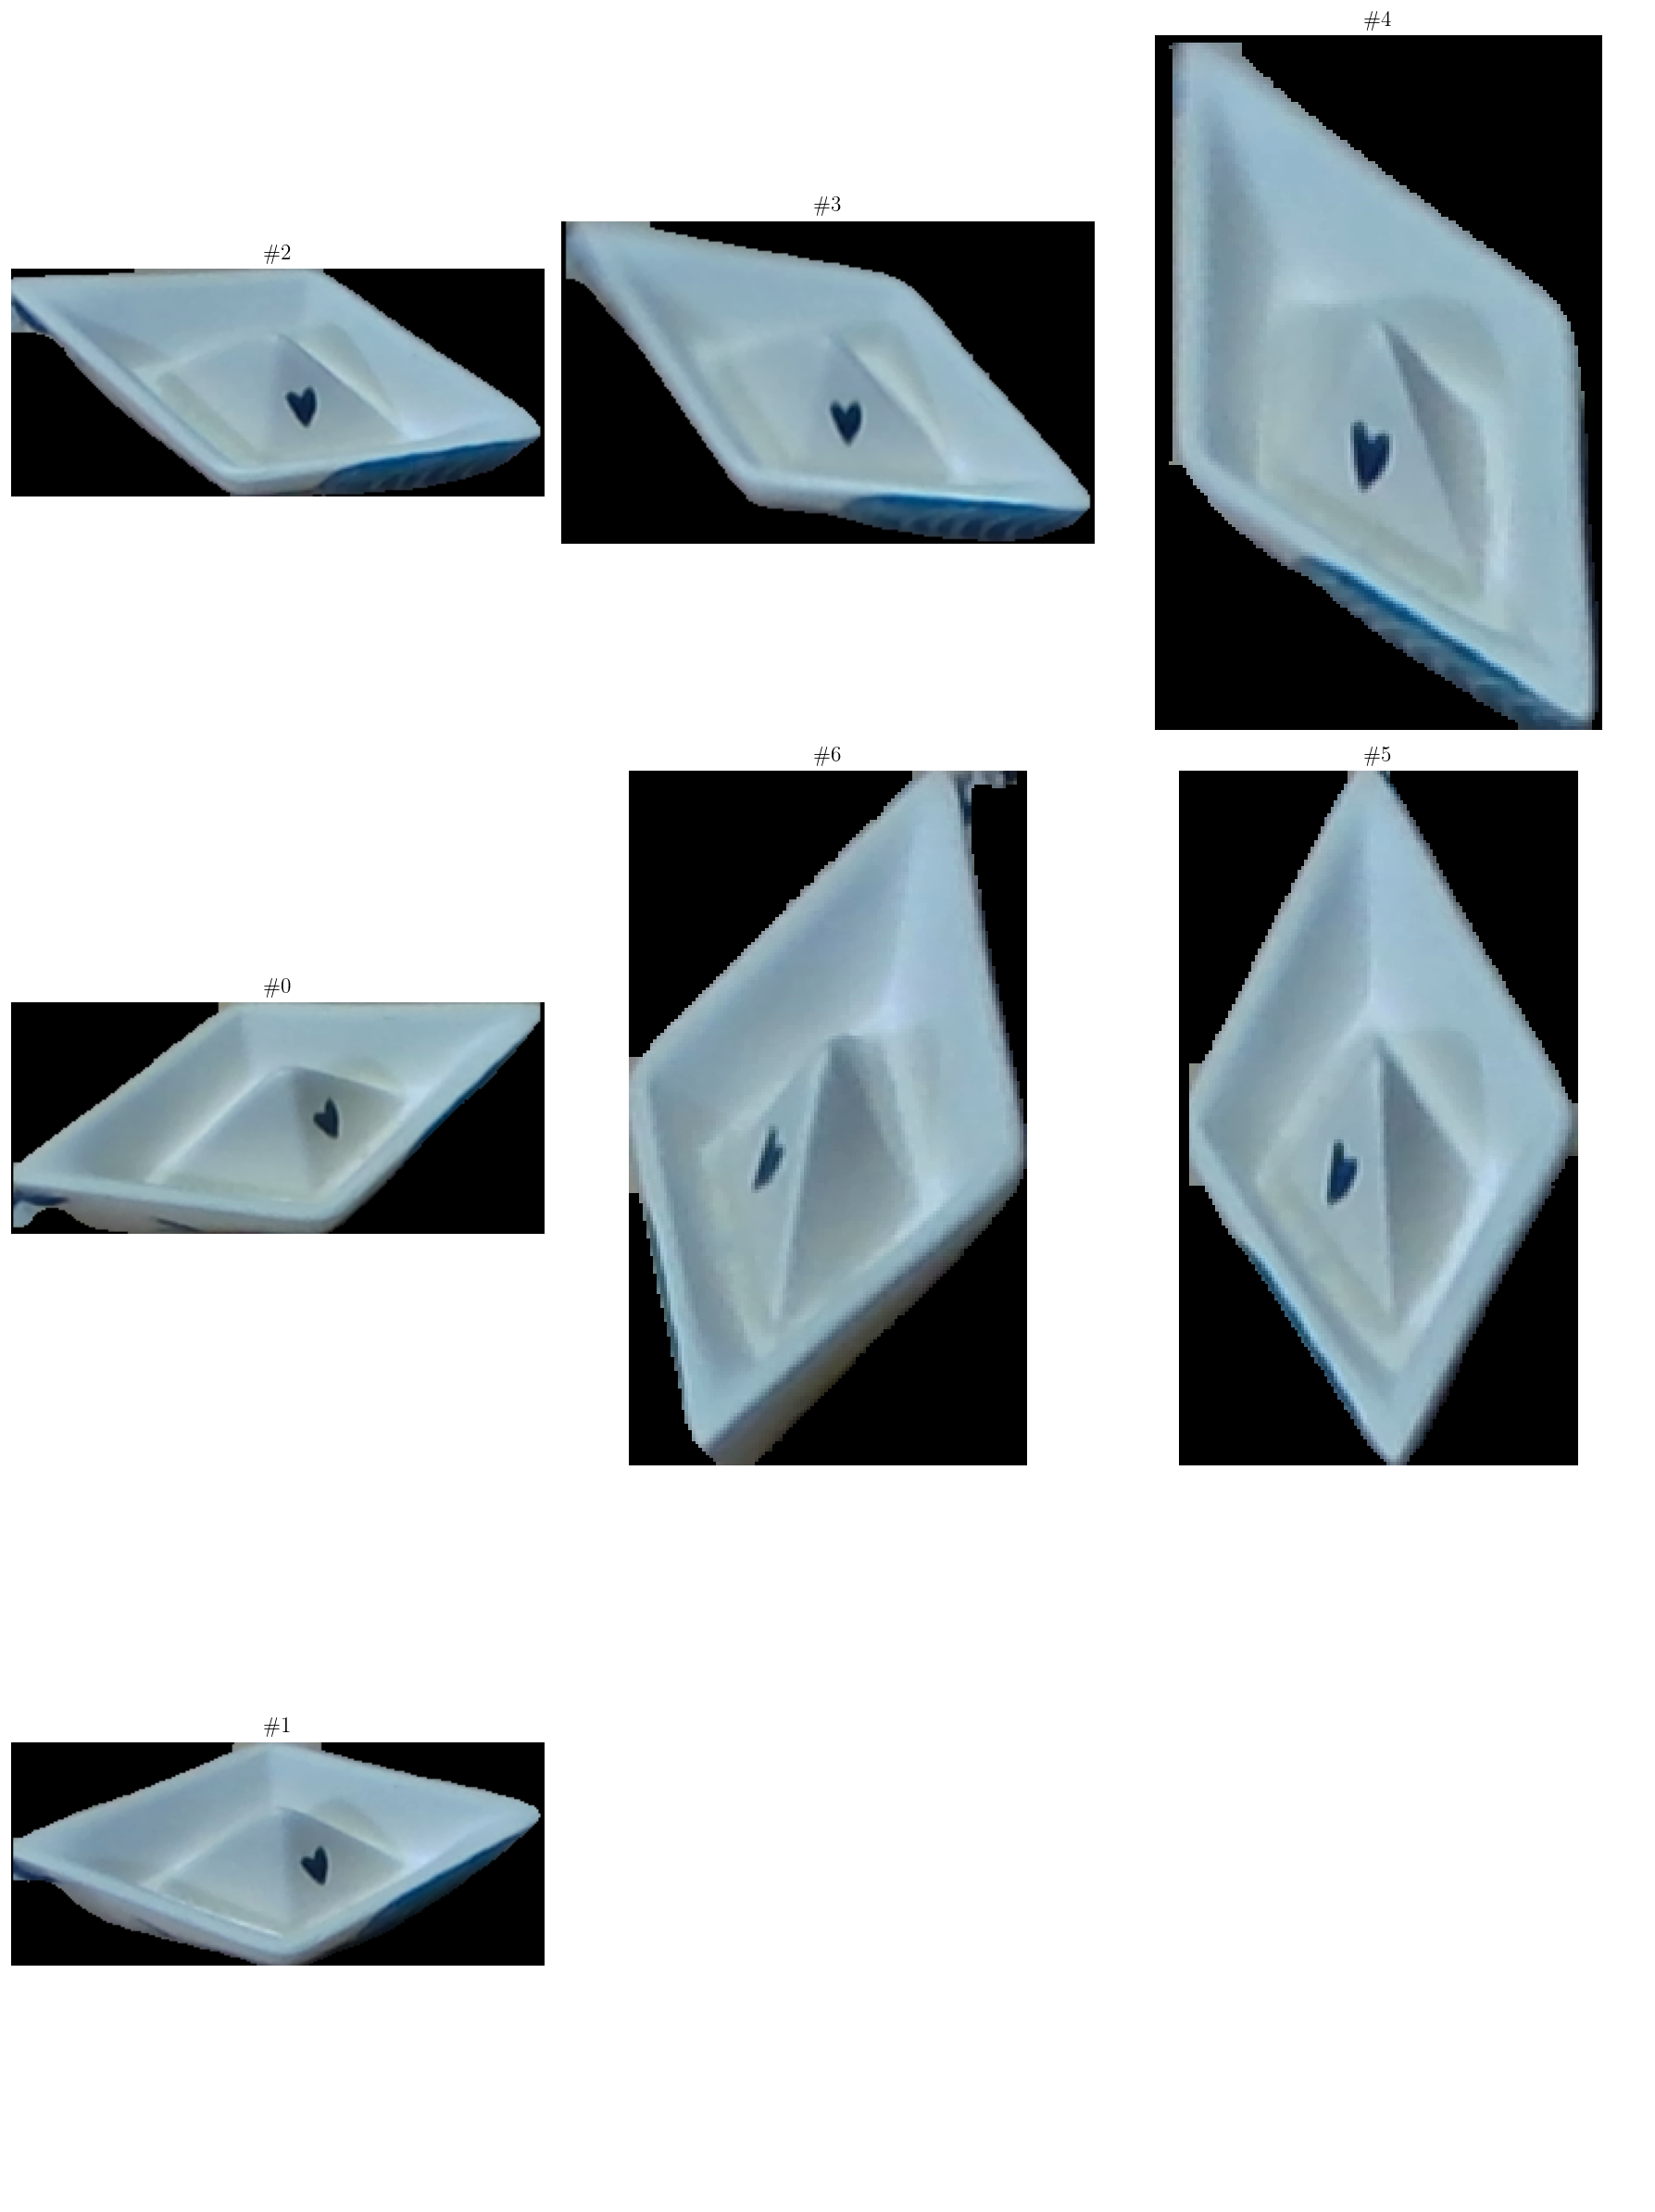

In [101]:
obj.show_snapshots(n=min(12, obj.num_snapshots))

In [102]:
valid = traj.valid

t = np.array([pose.timestamp for pose in valid])
t = t - t[0]

pos = np.array([pose.pos for pose in valid], dtype=np.float32)
rot = np.array([pose.rot for pose in valid], dtype=np.float32)

pos.shape, rot.shape

((192, 3), (192, 3))

## Quality summary


In [103]:
def counts(values):
    values = [str(v) for v in values if v is not None]
    if not values:
        return {}

    labels, freqs = np.unique(values, return_counts=True)
    return {label: int(freq) for label, freq in zip(labels, freqs)}


def metric_stats(records, key):
    values = [d.get(key) for d in records]
    values = np.array([
        v for v in values
        if isinstance(v, (int, float, np.integer, np.floating)) and np.isfinite(v)
    ], dtype=np.float64)

    if len(values) == 0:
        return {}

    return {
        f'{key}_mean': float(values.mean()),
        f'{key}_median': float(np.median(values)),
        f'{key}_min': float(values.min()),
        f'{key}_max': float(values.max()),
    }


pose_records = list(traj)
num_poses = len(pose_records)
num_valid = traj.num_valid
num_lost = num_poses - num_valid
success_diag = [d for d in diag if d.get('success')]
failure_diag = [d for d in diag if d.get('success') is False]
num_estimated = len(success_diag)
num_propagated = max(num_valid - num_estimated, 0)

quality_summary = {
    'scene_file': scene_path.name,
    'object_id': int(obj_id),
    'num_snapshots': int(obj.num_snapshots),
    'num_poses': int(num_poses),
    'num_valid_poses': int(num_valid),
    'num_lost_poses': int(num_lost),
    'num_estimated_poses': int(num_estimated),
    'num_propagated_poses': int(num_propagated),
    'valid_pose_ratio': float(num_valid / num_poses) if num_poses else 0.0,
    'estimated_pose_ratio': float(num_estimated / num_poses) if num_poses else 0.0,
    'estimated_valid_pose_ratio': float(num_estimated / num_valid) if num_valid else 0.0,
    'estimator_success_ratio': float(num_estimated / len(diag)) if diag else 0.0,
    'duration_s': float(t[-1]) if len(t) else 0.0,
    'num_pose_diagnostics': int(len(diag)),
    'num_pose_success': int(num_estimated),
    'num_pose_failure': int(len(failure_diag)),
    'solver_counts': counts(d.get('solver') for d in diag),
    'reason_counts': counts(d.get('reason') for d in diag),
}

for key in ('raw_matches', 'score_matches', 'mask_matches', 'ref_3d_points', 'live_3d_points', 'pnp_inliers'):
    quality_summary.update(metric_stats(diag, key))

for key, value in quality_summary.items():
    print(f'{key}: {value}')

if num_propagated > num_estimated:
    print('note: most valid poses are bbox-propagated, not fresh geometric estimates.')


scene_file: scene_crop_b=8_bt=0.5_pe=1_pose-rot_boat.joblib
object_id: 1
num_snapshots: 7
num_poses: 201
num_valid_poses: 192
num_lost_poses: 9
num_estimated_poses: 15
num_propagated_poses: 177
valid_pose_ratio: 0.9552238805970149
estimated_pose_ratio: 0.07462686567164178
estimated_valid_pose_ratio: 0.078125
estimator_success_ratio: 0.625
duration_s: 32.8458731174469
num_pose_diagnostics: 24
num_pose_success: 15
num_pose_failure: 9
solver_counts: {np.str_('rigid3d'): 15}
reason_counts: {np.str_('not_enough_feature_matches'): 9, np.str_('ok'): 15}
raw_matches_mean: 90.375
raw_matches_median: 47.5
raw_matches_min: 0.0
raw_matches_max: 314.0
score_matches_mean: 23.5
score_matches_median: 9.0
score_matches_min: 1.0
score_matches_max: 117.0
mask_matches_mean: 16.916666666666668
mask_matches_median: 8.5
mask_matches_min: 0.0
mask_matches_max: 67.0
ref_3d_points_mean: 16.833333333333332
ref_3d_points_median: 8.5
ref_3d_points_min: 0.0
ref_3d_points_max: 67.0
live_3d_points_mean: 16.7916666666

## Filter diagnostics


online filter diagnostics: 15 poses
position RMS [cm]: [   0.027193    0.064904     0.03363]
rotation RMS [deg]: [     2.8359     0.88119      2.7932]


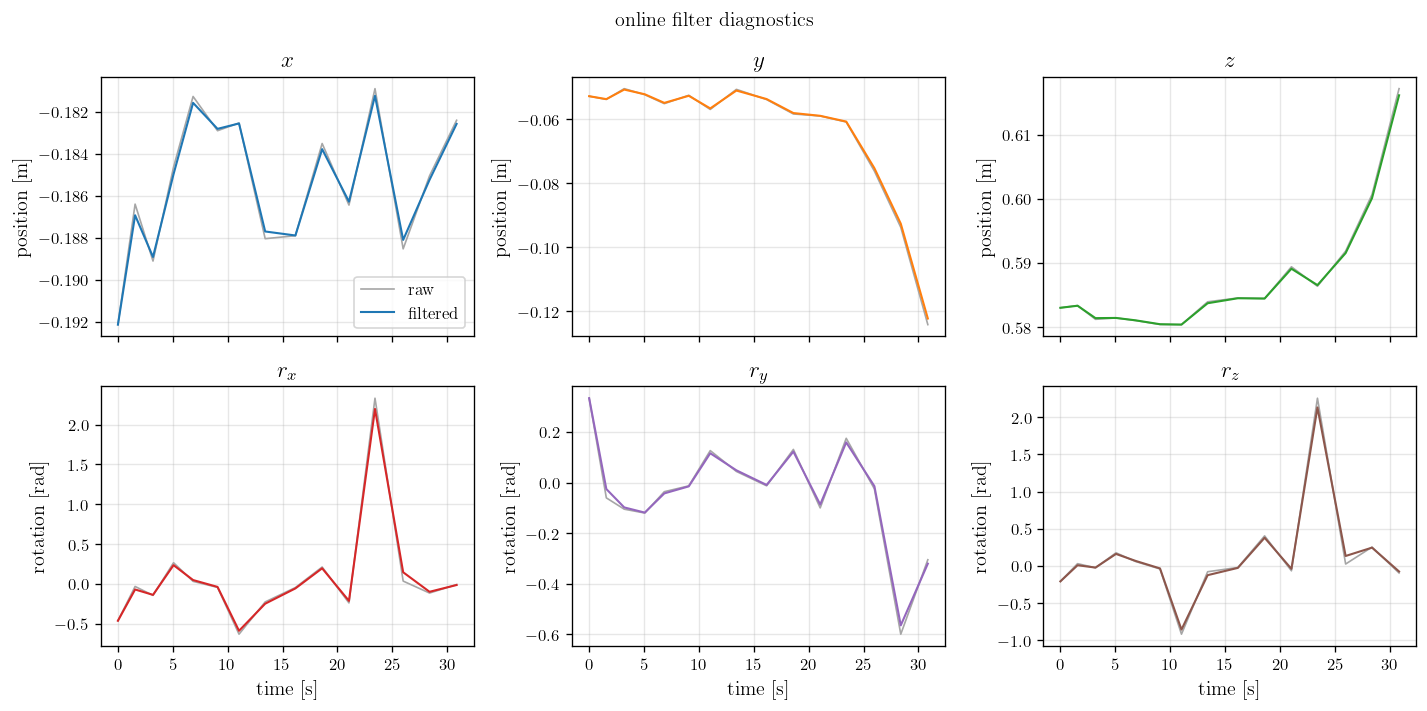

In [104]:
filter_diag = [
    d for d in diag
    if d.get('success')
    and d.get('raw_pose') is not None
    and d.get('filtered_pose') is not None
]

if filter_diag:
    ft = np.array([d['timestamp'] for d in filter_diag], dtype=np.float64)
    ft = ft - ft[0]
    raw_pose = np.array([d['raw_pose'] for d in filter_diag], dtype=np.float32)
    filt_pose = np.array([d['filtered_pose'] for d in filter_diag], dtype=np.float32)
    filter_title = 'online filter diagnostics'
else:
    ft = t
    raw_pose = np.hstack([pos, rot]).astype(np.float32)
    filters = [OneEuroFilter(min_cutoff=1.0, beta=0.2, d_cutoff=1.0) for _ in range(6)]
    filt_pose = np.array([
        [f(value, t=float(ti)) for f, value in zip(filters, pose)]
        for ti, pose in zip(ft, raw_pose)
    ], dtype=np.float32)
    filter_title = 'offline filter preview'
    print('No raw/filtered diagnostics stored in this scene; using trajectory as offline input.')

delta = filt_pose - raw_pose
pos_rms = np.sqrt(np.mean((delta[:, :3] * 100) ** 2, axis=0))
rot_rms = np.sqrt(np.mean(np.rad2deg(delta[:, 3:]) ** 2, axis=0))

print(f'{filter_title}: {len(raw_pose)} poses')
print(f'position RMS [cm]: {pos_rms}')
print(f'rotation RMS [deg]: {rot_rms}')

filter_summary = {
    'mode': filter_title,
    'num_poses': int(len(raw_pose)),
    'position_rms_cm': pos_rms.tolist(),
    'rotation_rms_deg': rot_rms.tolist(),
}

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(12, 6), sharex=True)

for i, label in enumerate(('x', 'y', 'z')):
    ax = axs[0, i]
    ax.plot(ft, raw_pose[:, i], color='0.65', linewidth=1, label='raw')
    ax.plot(ft, filt_pose[:, i], color=f'C{i}', linewidth=1.25, label='filtered')
    ax.set_title(rf'${label}$')
    ax.set_ylabel(r'position $[\mathrm{m}]$')
    ax.grid(alpha=0.3)

for i, label in enumerate(('r_x', 'r_y', 'r_z')):
    ax = axs[1, i]
    ax.plot(ft, np.unwrap(raw_pose[:, i + 3]), color='0.65', linewidth=1, label='raw')
    ax.plot(ft, np.unwrap(filt_pose[:, i + 3]), color=f'C{i + 3}', linewidth=1.25, label='filtered')
    ax.set_title(rf'${label}$')
    ax.set_ylabel(r'rotation $[\mathrm{rad}]$')
    ax.set_xlabel(r'time $[\mathrm{s}]$')
    ax.grid(alpha=0.3)

axs[0, 0].legend()
fig.suptitle(filter_title)
fig.tight_layout()
plt.show()


## Trajectory


/home/mcibula/Desktop/Projects/active-vision/src/structures/geometry.py:687: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(*p_traj[0], c=colors[0], s=30, label='Start')
/home/mcibula/Desktop/Projects/active-vision/src/structures/geometry.py:688: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(*p_traj[-1], c=colors[-1], marker='x', s=60, label='End')


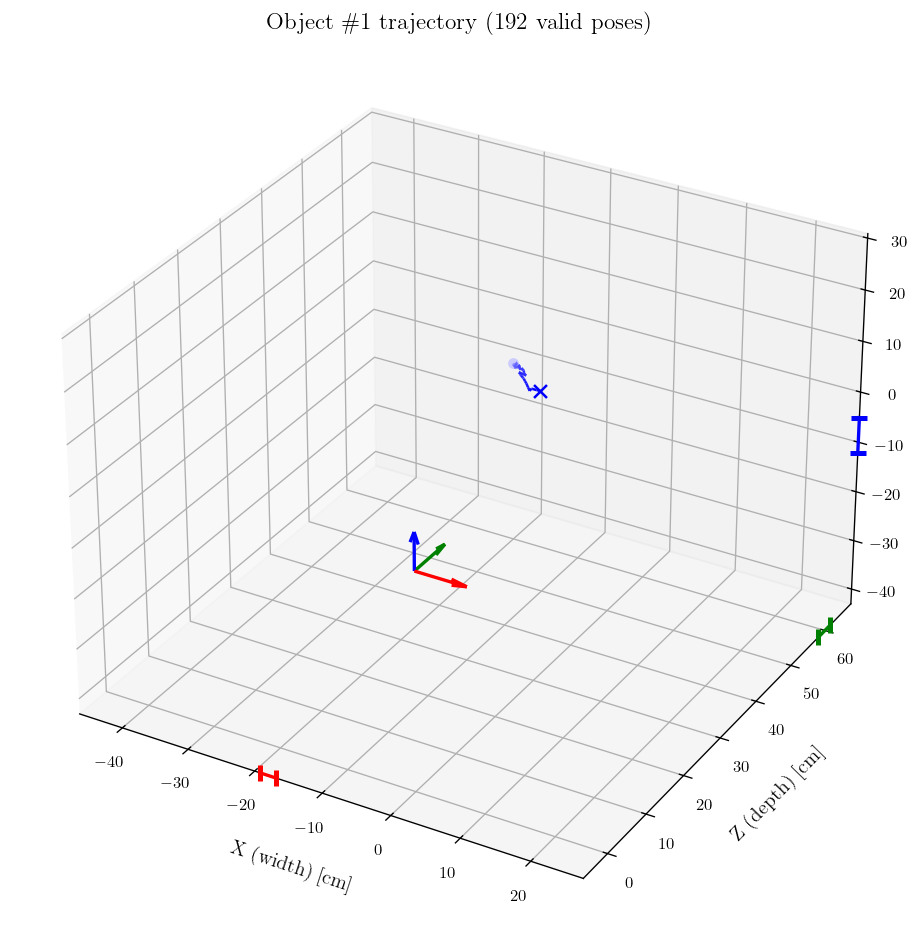

In [105]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

traj.plot(ax=ax, n_orient=0, show=False)
# ax.view_init(elev=0, azim=-20)
ax.set_title(rf'Object \#{obj_id} trajectory ({traj.num_valid} valid poses)')

fig.tight_layout()
plt.show()

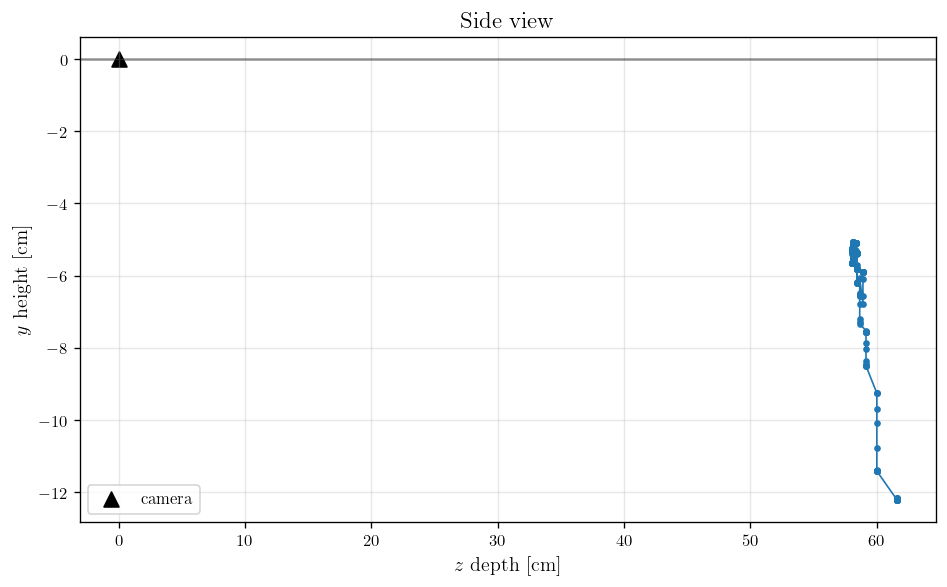

In [106]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(pos[:, 2] * 100, pos[:, 1] * 100, marker='.', linewidth=1)
ax.scatter([0], [0], marker='^', color='black', s=80, label='camera')
ax.axhline(0, color='black', alpha=0.4)

ax.set_xlabel(r'$z$ depth [cm]')
ax.set_ylabel(r'$y$ height [cm]')
ax.set_title('Side view')
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()

## Signals


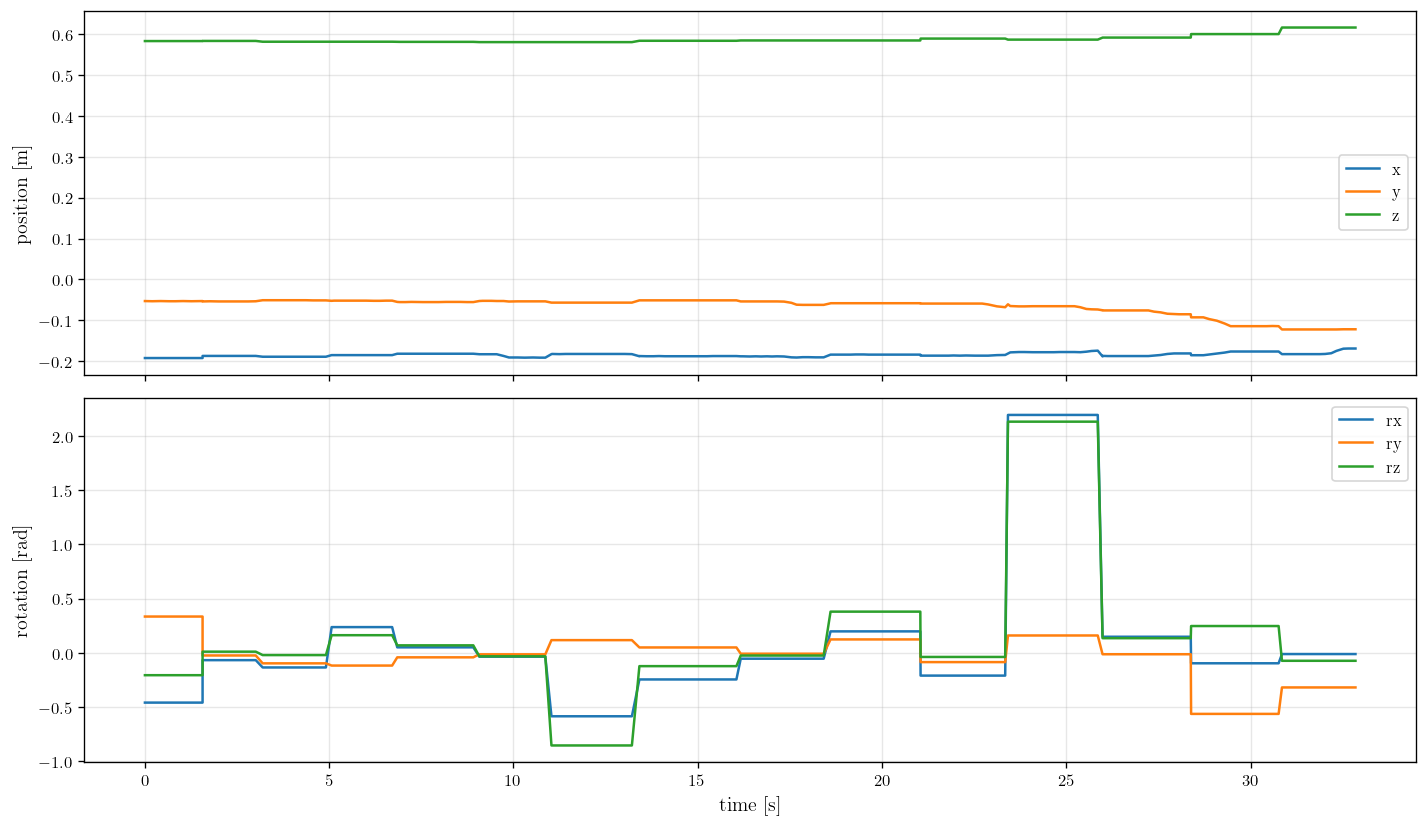

In [107]:
fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(12, 7), sharex=True)

for i, label in enumerate(('x', 'y', 'z')):
    ax1.plot(t, pos[:, i], label=label)

for i, label in enumerate(('rx', 'ry', 'rz')):
    ax2.plot(t, np.unwrap(rot[:, i]), label=label)

ax1.set_ylabel('position [m]')
ax2.set_ylabel(r'rotation $[\mathrm{rad}]$')
ax2.set_xlabel(r'time $[\mathrm{s}]$')

ax1.grid(alpha=0.3)
ax2.grid(alpha=0.3)
ax1.legend()
ax2.legend()

fig.tight_layout()
plt.show()

In [108]:
vectorizer = TrajVectorizer(target_len=60, num_pcoeffs=15, num_rcoeffs=15)
traj_vec = vectorizer(traj)

traj_vec.shape, np.isfinite(traj_vec).all()

((90,), np.True_)

## DCT vector


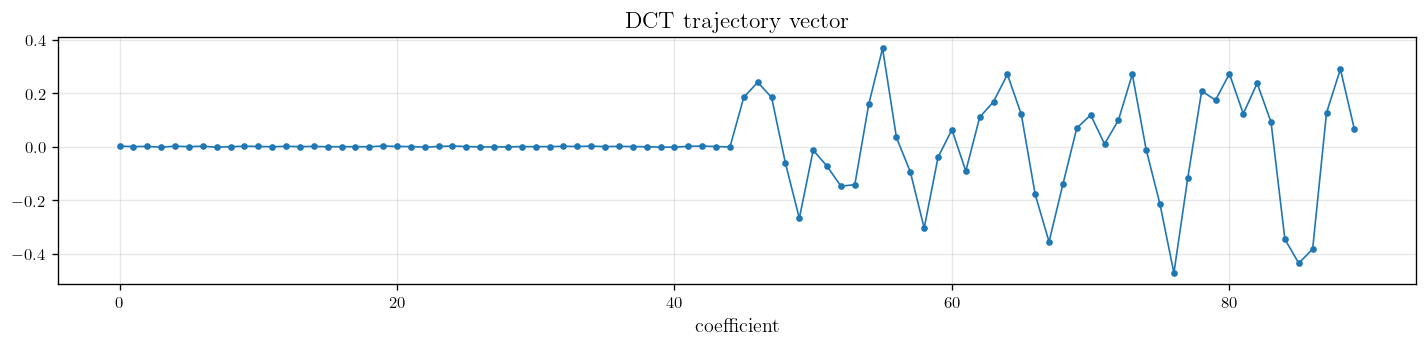

In [109]:
fig, ax = plt.subplots(figsize=(12, 3))

ax.plot(traj_vec, marker='.', linewidth=1)
ax.set_title('DCT trajectory vector')
ax.set_xlabel('coefficient')
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## Export


In [110]:
export = True


def json_safe(value):
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(v) for v in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, Path):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value

    return str(value)


if export:
    out_dir = Path('trajectory_exports')
    out_dir.mkdir(exist_ok=True)

    export_stem = f'{scene_path.stem}_obj-{obj_id}'
    npz_path = out_dir / f'{export_stem}.npz'
    csv_path = out_dir / f'{export_stem}_poses.csv'
    json_path = out_dir / f'{export_stem}.json'

    np.savez_compressed(
        npz_path,
        t=t,
        pos=pos,
        rot=rot,
        traj_vec=traj_vec,
        filter_t=ft,
        raw_pose=raw_pose,
        filtered_pose=filt_pose,
    )

    pose_table = np.column_stack([t, pos, rot])
    np.savetxt(
        csv_path,
        pose_table,
        delimiter=',',
        header='t,x,y,z,rx,ry,rz',
        comments=''
    )

    metadata = {
        'scene_file': scene_path.name,
        'scene_path': str(scene_path),
        'object_id': int(obj_id),
        'export_stem': export_stem,
        'files': {
            'npz': str(npz_path),
            'csv': str(csv_path),
            'json': str(json_path),
        },
        'axis_order': {
            'pos': ['x', 'y', 'z'],
            'rot': ['rx', 'ry', 'rz'],
            'pose_6d': ['x', 'y', 'z', 'rx', 'ry', 'rz'],
        },
        'trajectory_vectorizer': {
            'target_len': int(vectorizer.target_len),
            'num_pcoeffs': int(vectorizer.n_pos),
            'num_rcoeffs': int(vectorizer.n_rot),
            'output_dim': int(len(traj_vec)),
        },
        'quality_summary': quality_summary,
        'filter_summary': filter_summary,
        'pose_diagnostics': diag,
    }

    with json_path.open('w') as f:
        json.dump(json_safe(metadata), f, indent=2)

    print(f'exported {npz_path}')
    print(f'exported {csv_path}')
    print(f'exported {json_path}')


exported trajectory_exports/scene_crop_b=8_bt=0.5_pe=1_pose-rot_boat_obj-1.npz
exported trajectory_exports/scene_crop_b=8_bt=0.5_pe=1_pose-rot_boat_obj-1_poses.csv
exported trajectory_exports/scene_crop_b=8_bt=0.5_pe=1_pose-rot_boat_obj-1.json
